# Imports and Load

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.experimental import enable_halving_search_cv
enable_halving_search_cv
from sklearn.model_selection import train_test_split, HalvingRandomSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score
import xgboost as xgb
import mlflow
import optuna
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("customer-churn")

<Experiment: artifact_location='file:D:/Documents/ds-ml-portfolio/mlflow-server/mlruns/1', creation_time=1773772157776, experiment_id='1', last_update_time=1773772157776, lifecycle_stage='active', name='customer-churn', tags={}, workspace='default'>

In [2]:
with open('./data/train.csv', 'r') as f:
    df = pd.read_csv(f)

In [3]:
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


# 1. EDA

In [4]:
df_eda = df.copy()
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [5]:
numeric_cols = []
categorical_cols = []

for col in df_eda.columns:
    if df_eda[col].dtype in ['object', 'str'] or df_eda[col].nunique() == 2:
        categorical_cols.append(col)
    elif df_eda[col].dtype in ['int64', 'float64']:
        if df_eda[col].nunique() < 6:
            categorical_cols.append(col)
        else:
            numeric_cols.append(col)

print(f"Numeric Columns: {numeric_cols}")
print(f"Categorical Columns: {categorical_cols}")

Numeric Columns: ['id', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [6]:
missing_values = df_eda.isnull().sum()
columns_with_nan = missing_values[missing_values > 0]

if not columns_with_nan.empty:
    print("Columns with NaN or null values:")
    print(columns_with_nan)

In [7]:
df_eda.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177263,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


### 1.1 Variáveis numéricas

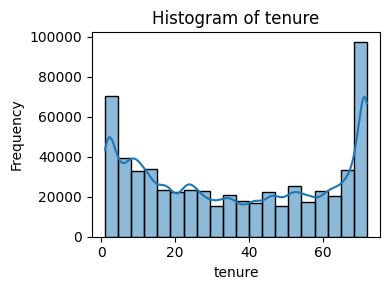

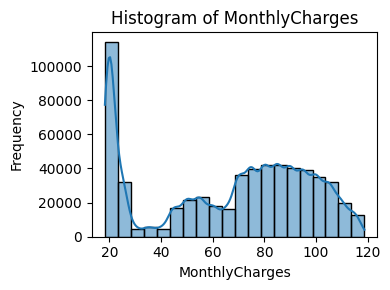

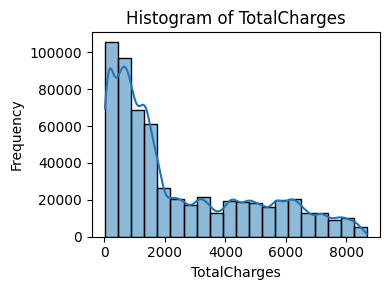

In [8]:
for column in numeric_cols:
    if column == "id":
        continue
    plt.figure(figsize=(4, 3))

    if df_eda[column].dtype == 'int64' and df_eda[column].nunique() <= 15:
        # For integer columns with few unique values, set bins to the number of unique values
        num_bins = df_eda[column].nunique()
        sns.histplot(df_eda[column], kde=False, bins=num_bins) # kde might not be meaningful for few bins
    elif df_eda[column].nunique() > 20:
        sns.histplot(df_eda[column], kde=True, bins=20)
    else:
        # For other numeric columns (floats or many unique integers), use 'auto' bins
        sns.histplot(df_eda[column], kde=True, bins='auto')

    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

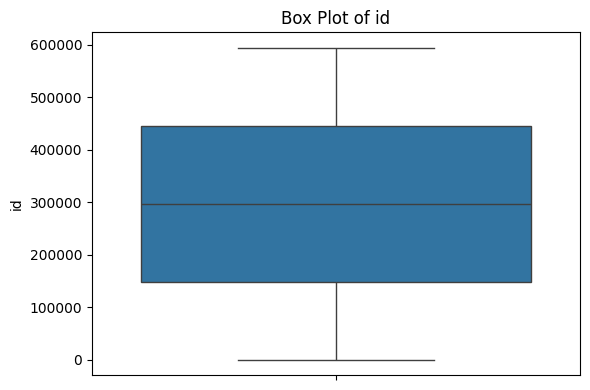

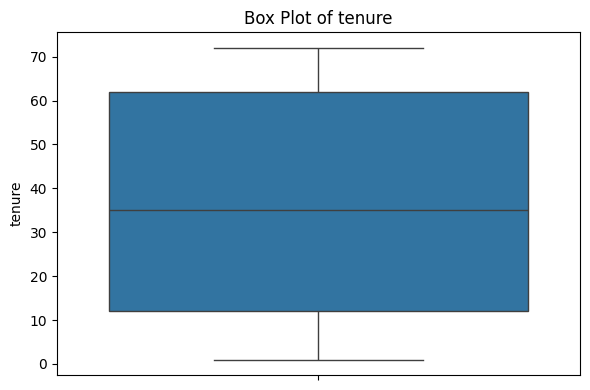

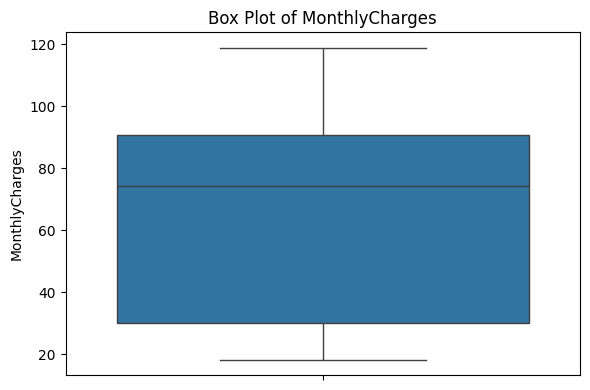

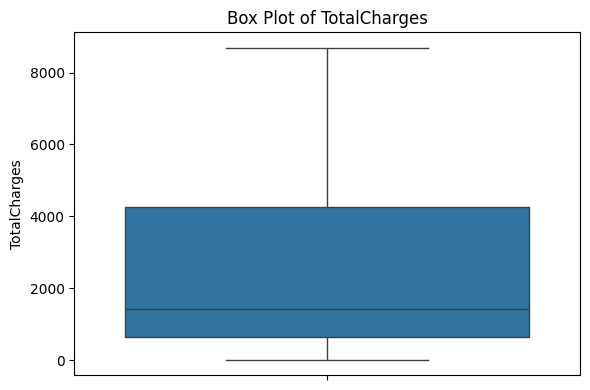

In [9]:
for column in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df_eda[column])
    plt.title(f'Box Plot of {column}')
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

### 1.2 Variáveis categóricas

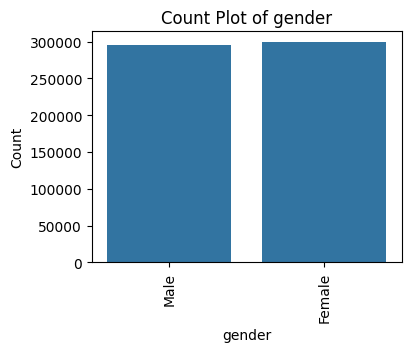

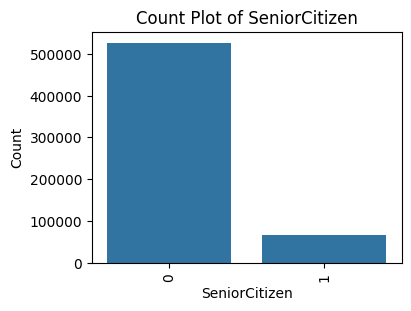

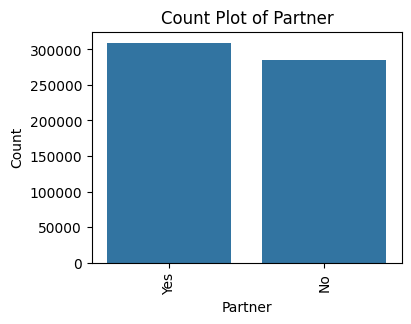

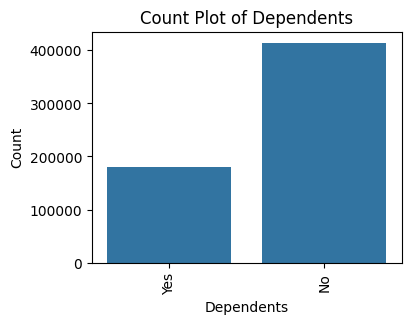

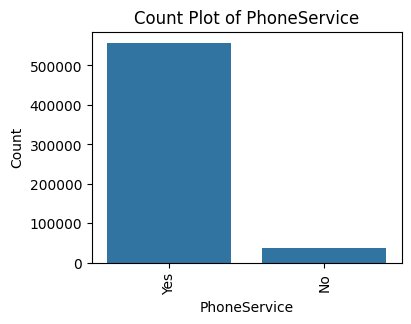

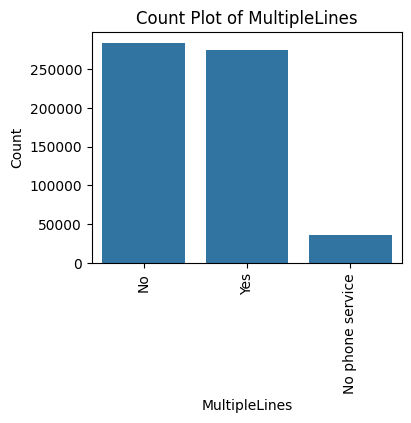

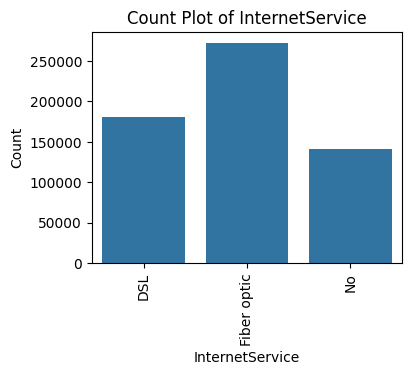

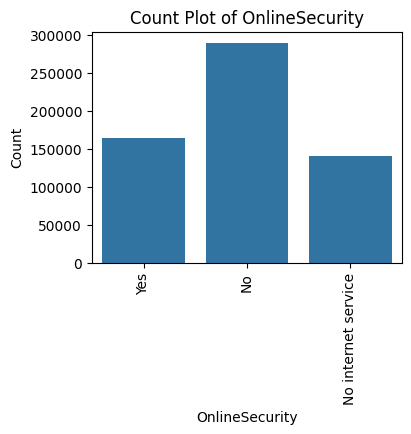

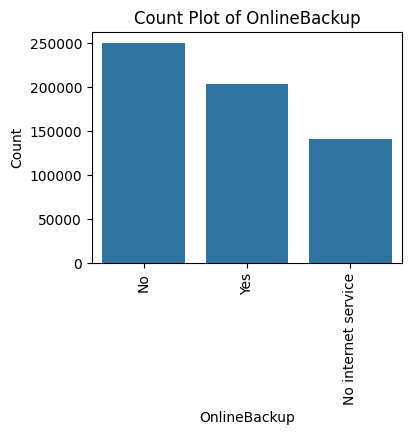

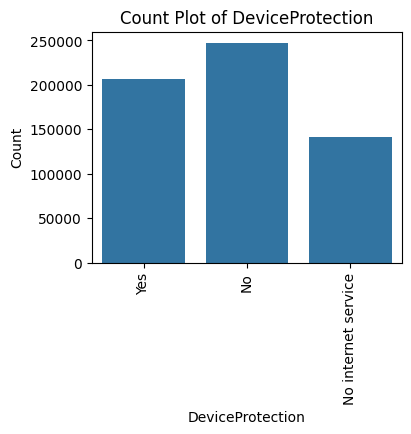

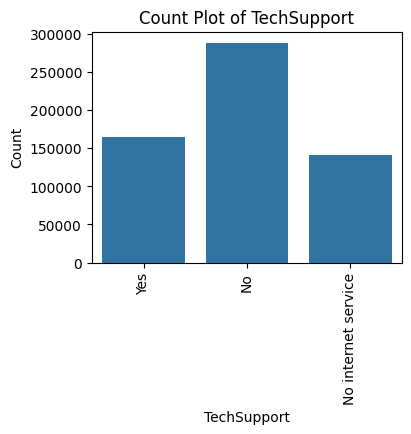

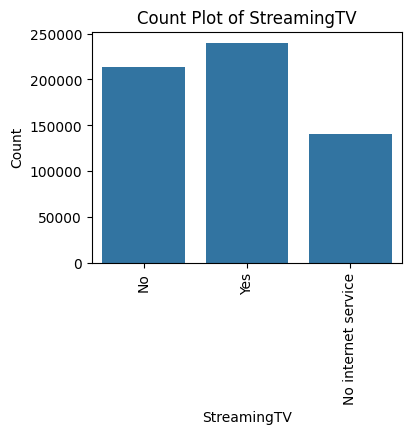

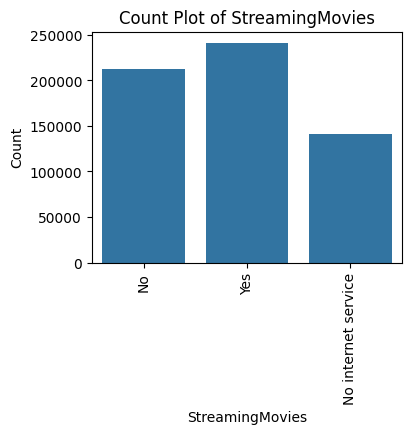

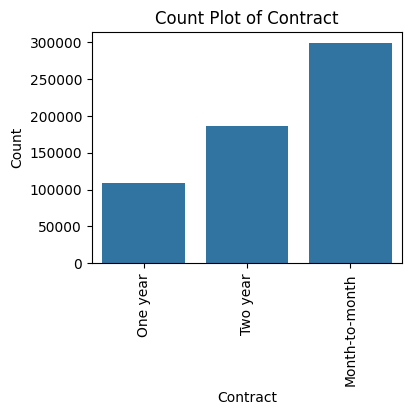

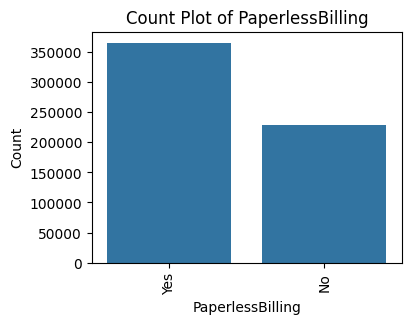

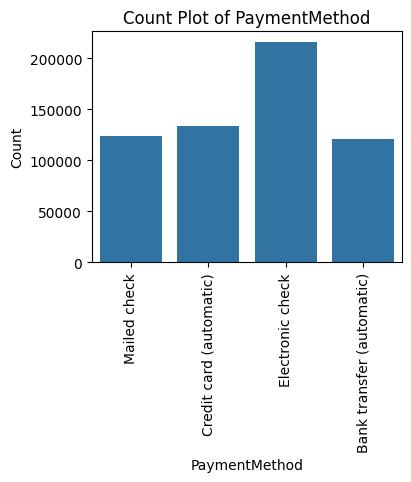

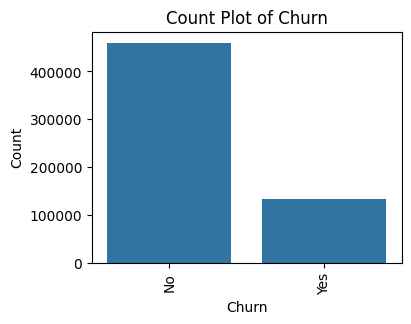

In [10]:
for column in categorical_cols:
    plt.figure(figsize=(4,3))
    sns.countplot(data=df_eda, x=column)
    plt.title(f'Count Plot of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.show()

### 1.3 Relação numéricas X numéricas

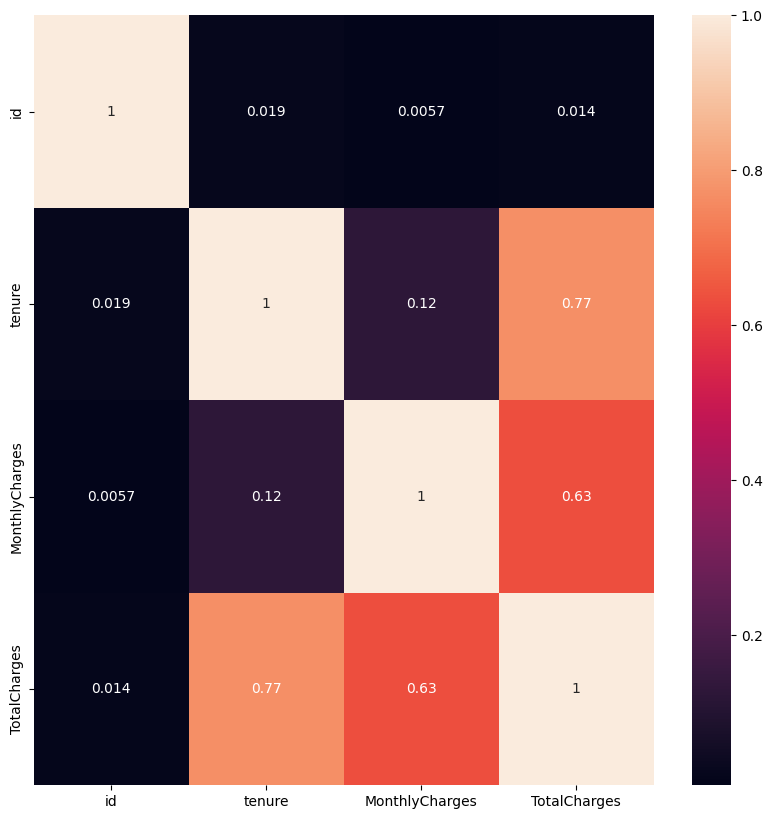

In [11]:
plt.figure(figsize=(10, 10))
sns.heatmap(df_eda[numeric_cols].corr(), annot=True)
plt.show()

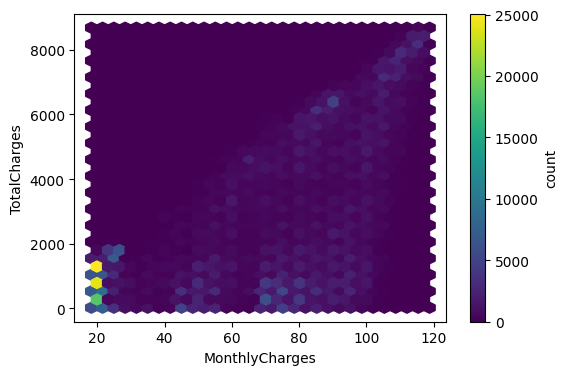

In [12]:
plt.figure(figsize=(6,4))
plt.hexbin(data=df_eda, x='MonthlyCharges', y='TotalCharges', gridsize=30)
plt.xlabel("MonthlyCharges")
plt.ylabel("TotalCharges")
plt.colorbar(label="count")
plt.show()

### 1.4 Relação target X numéricas

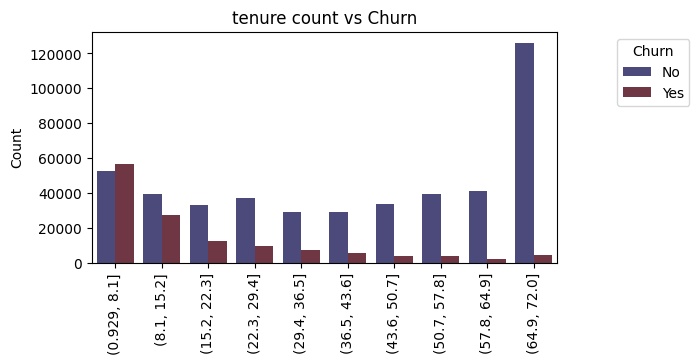

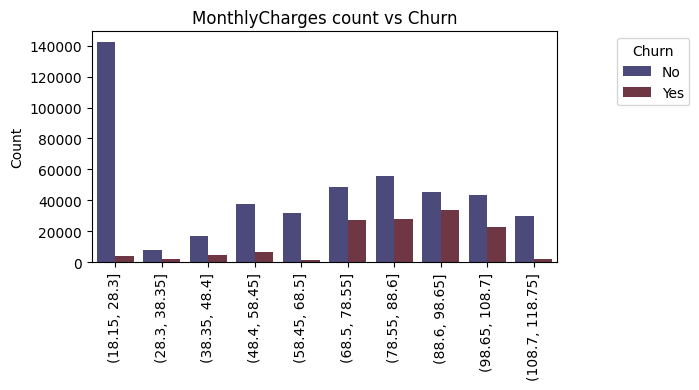

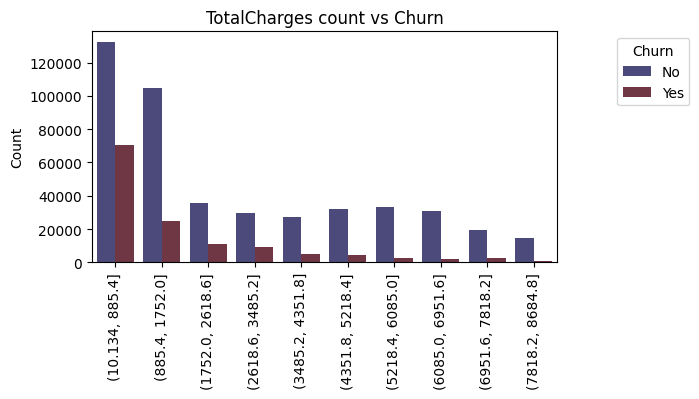

In [13]:
df_eda_countplot = df_eda.copy()

for col in numeric_cols:
    if col == "Churn" or col == "id":
        continue
    if df_eda_countplot[col].nunique() > 10:
        df_eda_countplot[col] = pd.cut(df_eda_countplot[col], bins=10)
    plt.figure(figsize=(6, 3))
    ax = sns.countplot(data=df_eda_countplot, x=col, hue='Churn', palette="icefire")
    sns.move_legend(ax, "upper right", bbox_to_anchor=(1.3, 1))
    plt.title(f'{col} count vs Churn')
    plt.xlabel('')
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.show()

### 1.5 Relação target X categóricas

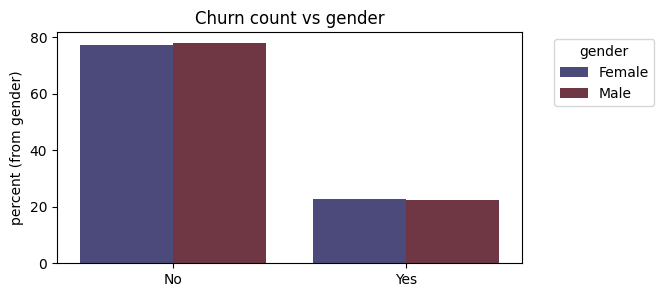

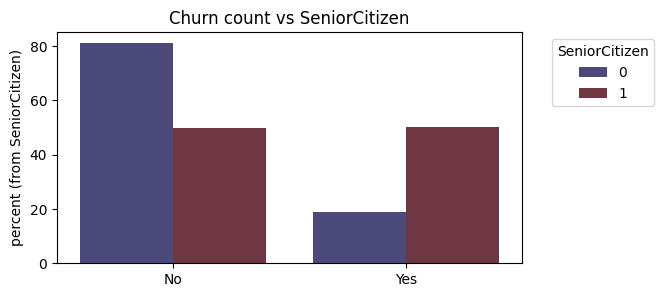

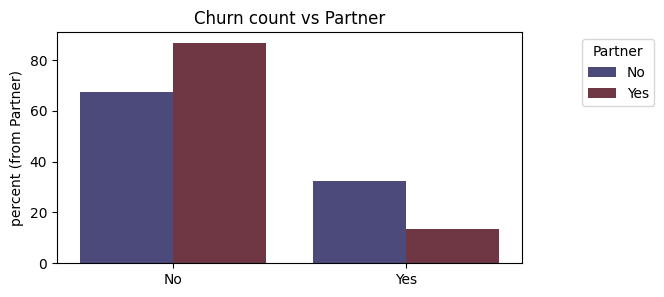

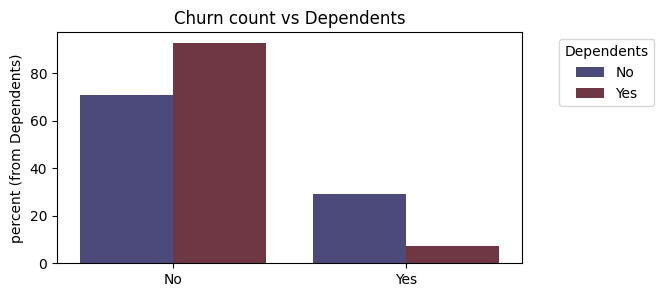

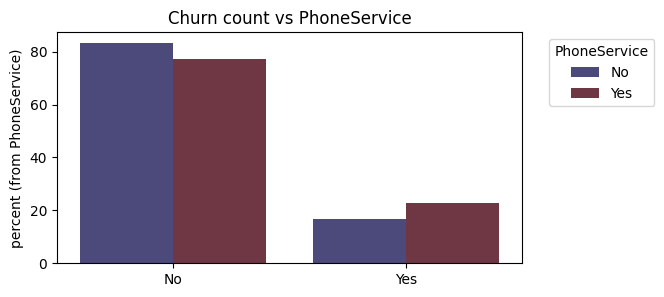

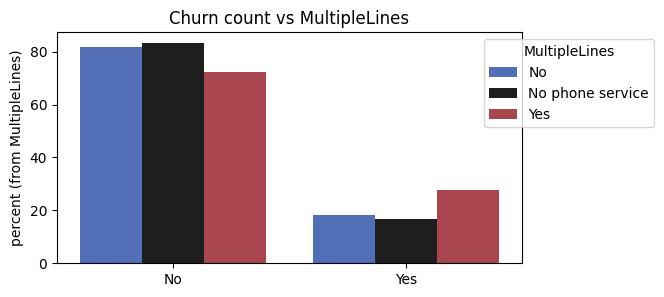

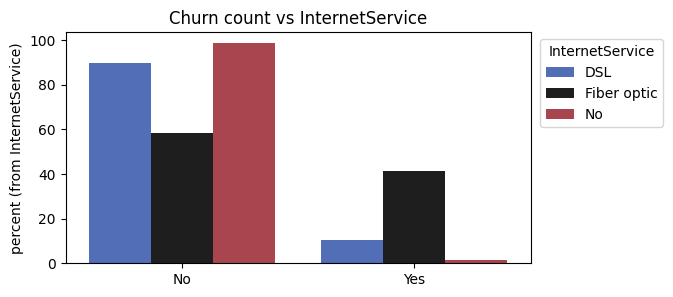

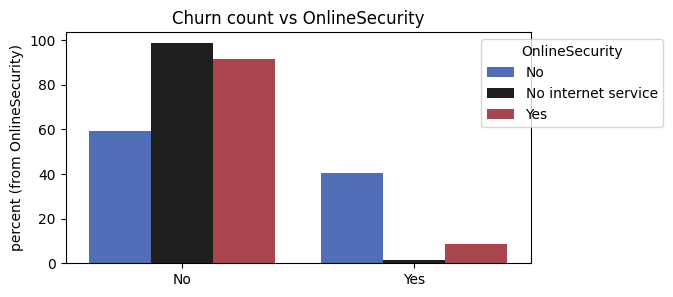

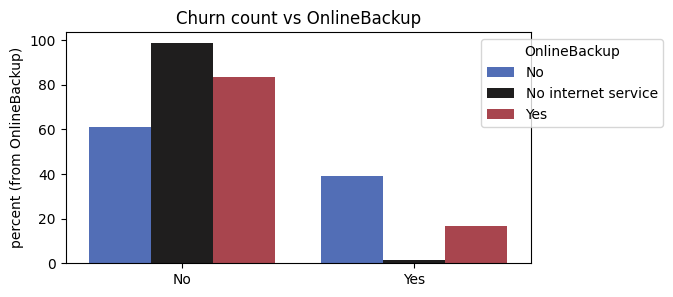

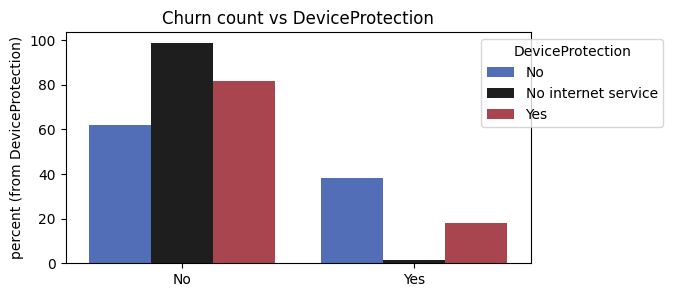

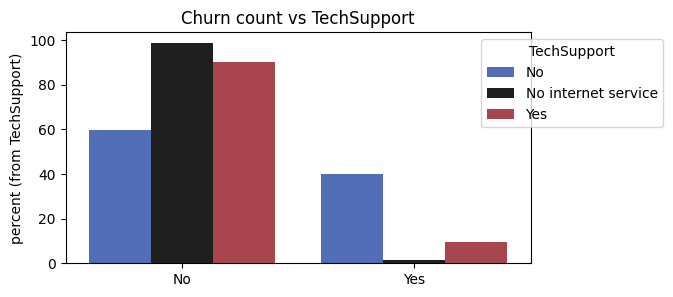

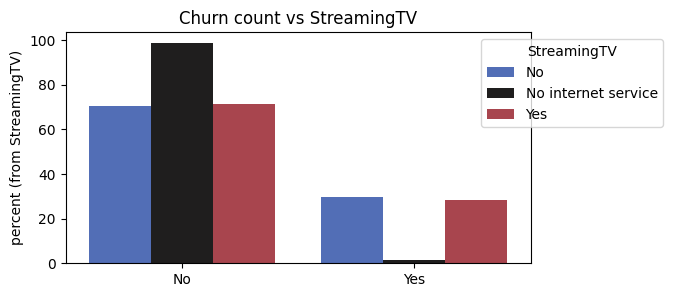

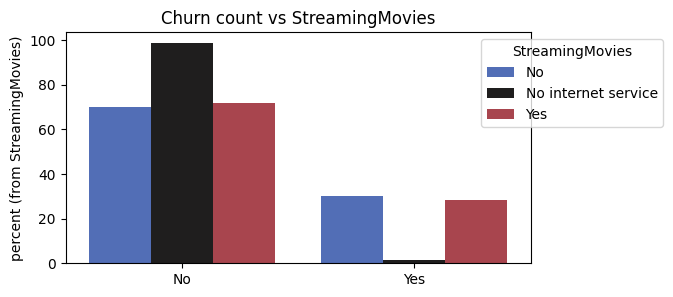

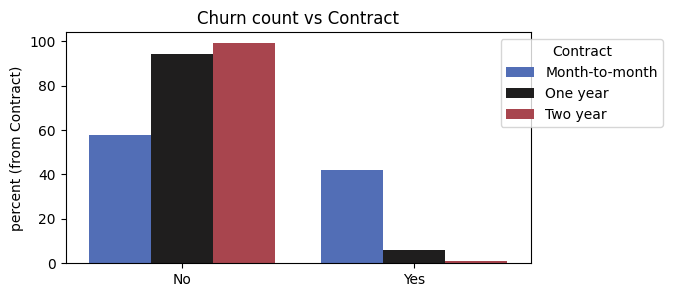

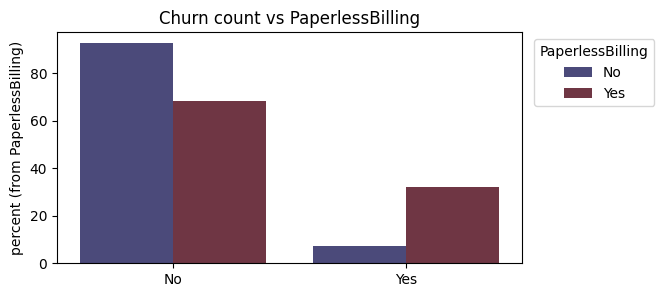

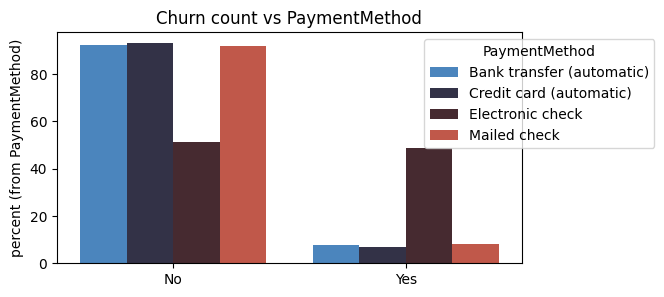

In [14]:
df_eda_countplot_perc = df_eda_countplot.copy()
for col in categorical_cols:
    if col == "Churn":
        continue
    df_pct = (
        df_eda_countplot_perc
        .groupby(["Churn", col], as_index=False, observed=True)
        .size()
    )

    df_pct["percent"] = (
        df_pct.groupby(col, observed=True)["size"]
        .transform(lambda x: x * 100 / x.sum())
    )

    plt.figure(figsize=(6, 3))
    ax = sns.barplot(
        data=df_pct,
        x="Churn",
        y="percent",
        hue=col,
        palette="icefire"
    )
    sns.move_legend(ax, "upper right", bbox_to_anchor=(1.3, 1))
    plt.title(f'Churn count vs {col}')
    plt.xlabel('')
    plt.ylabel(f'percent (from {col})')
    plt.show()

---
## 1.8 Análises e conclusões

lorem ipsum

---
# 2. Data Wrangling

---
# 3. Dataset split

In [15]:
df_copy = df.copy()
df_copy = df_copy.drop("id", axis=1)
numeric_cols_ = numeric_cols.copy()
numeric_cols_.remove("id")
categorical_cols_ = categorical_cols.copy()
categorical_cols_.remove("Churn")
X = df_copy.drop("Churn", axis=1)
X = pd.concat([
    X.select_dtypes([], ['object']),
    X.select_dtypes(['object']).apply(pd.Series.astype, dtype='category')
    ], axis=1)


y = df_copy["Churn"].map({"No": 0, "Yes": 1})

X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# 4. Modeling

## 4.1. XGBoost with HalvingRandomSearchCV

In [22]:
mlflow.set_experiment("customer-churn")

with mlflow.start_run():
    model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        enable_categorical=True,
        scale_pos_weight = 460000 / 133000,
        n_jobs=1
    )

    param_grid = {
        'max_depth': [2, 4, 8, 16, 32],
        'learning_rate': [0.01, 0.1, 0.3],
        'booster': ['gbtree'],
        'subsample': [0.8, 1],
        'colsample_bytree': [0.8, 1],
        'min_child_weight': [1, 3, 5, 7],
        'gamma': [0, 0.1, 0.3, 1],
        'reg_alpha': [0, 0.1, 1, 10],
        'reg_lambda': [0, 0.5, 1, 5, 10],

    }

    cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )
    search = HalvingRandomSearchCV(
        estimator=model,
        param_distributions=param_grid,
        resource="n_estimators",
        min_resources=200,
        max_resources=1000,
        factor=2,
        scoring="roc_auc",
        cv=cv,
        verbose=3,
        n_jobs=-1
    )

    search.fit(X_train, y_train)
    
    mlflow.log_param("n_estimators", search.best_params_['n_estimators'])
    mlflow.log_param("max_depth", search.best_params_['max_depth'])
    mlflow.log_param("learning_rate", search.best_params_['learning_rate'])
    mlflow.log_param("booster", search.best_params_['booster'])
    mlflow.log_param("subsample", search.best_params_['subsample'])
    mlflow.log_param("colsample_bytree", search.best_params_['colsample_bytree'])
    
    mlflow.sklearn.log_model(search.best_estimator_, 'best_halving_xgb_model')
    mlflow.log_metric("roc_auc", search.score(X_val, y_val))


    print("Best params:")
    print(search.best_params_)

    print("Best mean AUC:")
    print(search.best_score_)



n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 200
max_resources_: 1000
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 5
n_resources: 200
Fitting 3 folds for each of 5 candidates, totalling 15 fits
----------
iter: 1
n_candidates: 3
n_resources: 400
Fitting 3 folds for each of 3 candidates, totalling 9 fits
----------
iter: 2
n_candidates: 2
n_resources: 800
Fitting 3 folds for each of 2 candidates, totalling 6 fits


2026/03/17 16:23:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/17 16:23:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best params:
{'subsample': 1, 'reg_lambda': 10, 'reg_alpha': 0.1, 'min_child_weight': 7, 'max_depth': 16, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 1, 'booster': 'gbtree', 'n_estimators': 800}
Best mean AUC:
0.9109076424728118
🏃 View run respected-flea-102 at: http://localhost:5000/#/experiments/1/runs/b5d30727efe04c1facb4c74c281050c3
🧪 View experiment at: http://localhost:5000/#/experiments/1


## 4.2. XGBoost with Optuna

In [ ]:
# https://mlflow.org/docs/latest/ml/getting-started/hyperparameter-tuning/
mlflow.set_experiment("customer-churn-optuna")

def objective(trial):
    # Setting nested=True will create a child run under the parent run.
    with mlflow.start_run(nested=True, run_name=f"trial_{trial.number}") as child_run:
        model_max_depth = trial.suggest_int("model_max_depth", 2, 32)
        model_n_estimators = trial.suggest_int("model_n_estimators", 100, 1100, step=200)
        model_learning_rate = trial.suggest_categorical("model_learning_rate", [0.01, 0.1, 0.3])
        model_subsample = trial.suggest_categorical("model_subsample", [0.8, 1.0])
        model_colsample_bytree = trial.suggest_categorical("model_colsample_bytree", [0.8, 1.0])
        model_min_child_weight = trial.suggest_int("model_min_child_weight", 1, 7, step=2)
        model_gamma = trial.suggest_categorical("model_gamma", [0, 0.1, 0.3, 1])
        model_reg_alpha = trial.suggest_categorical("model_reg_alpha", [0, 0.1, 1, 10])
        model_reg_lambda = trial.suggest_categorical("model_reg_lambda", [0, 0.5, 1, 5, 10])

        params = {
            "max_depth": model_max_depth,
            "n_estimators": model_n_estimators,
            "learning_rate": model_learning_rate,
            "subsample": model_subsample,
            "colsample_bytree": model_colsample_bytree,
            "min_child_weight": model_min_child_weight,
            "gamma": model_gamma,
            "reg_alpha": model_reg_alpha,
            "reg_lambda": model_reg_lambda
        }
        # Log current trial's parameters
        mlflow.log_params(params)

        regressor_obj = xgb.XGBClassifier(
            objective='binary:logistic',
            eval_metric='auc',
            enable_categorical=True,
            n_jobs=1
        )
        regressor_obj.fit(X_train, y_train)

        y_pred = regressor_obj.predict(X_val)
        score = roc_auc_score(y_val, y_pred)
        # Log current trial's score metric
        mlflow.log_metrics({"score": score})

        # Log the model file
        mlflow.sklearn.log_model(regressor_obj, name="model")
        # Make it easy to retrieve the best-performing child run later
        trial.set_user_attr("run_id", child_run.info.run_id)
        return score


with mlflow.start_run(run_name="optuna-study") as run:
    # Log the experiment settings
    n_trials = 30
    mlflow.log_param("n_trials", n_trials)

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)

    # Log the best trial and its run ID
    mlflow.log_params(study.best_trial.params)
    mlflow.log_metrics({"best_error": study.best_value})
    if best_run_id := study.best_trial.user_attrs.get("run_id"):
        mlflow.log_param("best_child_run_id", best_run_id)



[I 2026-03-17 16:28:18,713] A new study created in memory with name: no-name-ddadf64f-75ff-4a27-b634-173fd5ad0112
2026/03/17 16:28:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
[I 2026-03-17 16:28:26,763] Trial 0 finished with value: 0.8397303790477593 and parameters: {'model_max_depth': 15, 'model_n_estimators': 900, 'model_learning_rate': 0.1, 'model_subsample': 1.0, 'model_colsample_bytree': 0.8, 'model_min_child_weight': 5, 'model_gamma': 1, 'model_reg_alpha': 0, 'model_reg_lambda': 1}. Best is trial 0 with value: 0.8397303790477593.


🏃 View run trial_0 at: http://localhost:5000/#/experiments/2/runs/37fa867047b5466b8d1489ffd8ad284e
🧪 View experiment at: http://localhost:5000/#/experiments/2


2026/03/17 16:28:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
[I 2026-03-17 16:28:34,173] Trial 1 finished with value: 0.8397303790477593 and parameters: {'model_max_depth': 27, 'model_n_estimators': 700, 'model_learning_rate': 0.01, 'model_subsample': 1.0, 'model_colsample_bytree': 0.8, 'model_min_child_weight': 7, 'model_gamma': 0.1, 'model_reg_alpha': 0, 'model_reg_lambda': 0.5}. Best is trial 0 with value: 0.8397303790477593.


🏃 View run trial_1 at: http://localhost:5000/#/experiments/2/runs/d36723e34c2b4b7ea818c69db213a388
🧪 View experiment at: http://localhost:5000/#/experiments/2


2026/03/17 16:28:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
[I 2026-03-17 16:28:41,692] Trial 2 finished with value: 0.8397303790477593 and parameters: {'model_max_depth': 21, 'model_n_estimators': 500, 'model_learning_rate': 0.1, 'model_subsample': 0.8, 'model_colsample_bytree': 0.8, 'model_min_child_weight': 3, 'model_gamma': 0.3, 'model_reg_alpha': 10, 'model_reg_lambda': 0.5}. Best is trial 0 with value: 0.8397303790477593.


...

🏃 View run trial_9 at: http://localhost:5000/#/experiments/2/runs/a00babcdd8cc4c58a93eb4ec3f72ca72
🧪 View experiment at: http://localhost:5000/#/experiments/2


2026/03/17 16:29:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
[I 2026-03-17 16:29:40,592] Trial 10 finished with value: 0.8397303790477593 and parameters: {'model_max_depth': 12, 'model_n_estimators': 300, 'model_learning_rate': 0.1, 'model_subsample': 0.8, 'model_colsample_bytree': 0.8, 'model_min_child_weight': 5, 'model_gamma': 1, 'model_reg_alpha': 0.1, 'model_reg_lambda': 1}. Best is trial 0 with value: 0.8397303790477593.


🏃 View run trial_10 at: http://localhost:5000/#/experiments/2/runs/6a47ce5dde7140e59f035e989c416d55
🧪 View experiment at: http://localhost:5000/#/experiments/2


2026/03/17 16:29:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
[I 2026-03-17 16:29:47,880] Trial 11 finished with value: 0.8397303790477593 and parameters: {'model_max_depth': 31, 'model_n_estimators': 900, 'model_learning_rate': 0.01, 'model_subsample': 1.0, 'model_colsample_bytree': 0.8, 'model_min_child_weight': 5, 'model_gamma': 0.1, 'model_reg_alpha': 0, 'model_reg_lambda': 1}. Best is trial 0 with value: 0.8397303790477593.


🏃 View run trial_11 at: http://localhost:5000/#/experiments/2/runs/6cd19788cbe743fca15f59eac7a75640
🧪 View experiment at: http://localhost:5000/#/experiments/2
